In [11]:
import pandas as pd
import random

In [12]:
'''suppose We throw a dice , X is a random variable and X is a outcome of dice 
x ɛ {1,2,3,4,5,6}
we roll a dice 10000 times and than calculating Probability Distribution
probality is equally likely (1/6) 
'''
L = []
for i in range(0,1000):
    L.append(random.randint(1,6))

<Axes: >

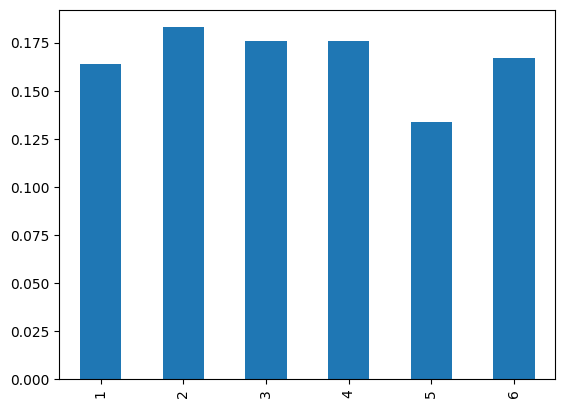

In [13]:
s = pd.Series(L)
(s.value_counts()/len(s)).sort_index().plot(kind='bar')

In [14]:
# since the outcomes are random its approx distrete uniform

<Axes: >

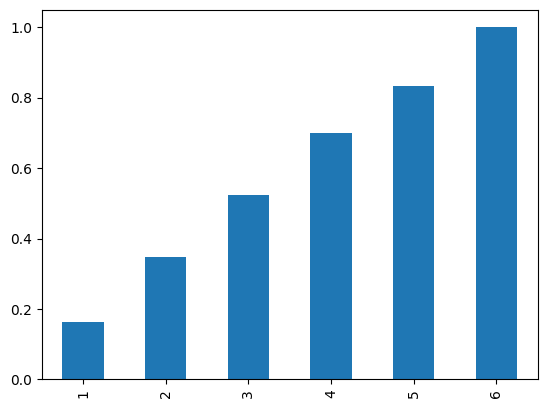

In [15]:
# CDF in PMF
(s.value_counts().sort_index()/len(s)).cumsum().plot(kind='bar')

In [16]:
''' Tossing 2 dice 1000 times simultaneouly,Here X is Sum of resulting output produce by these  2 dices '''
L =  []
for i in range(1000):
    a = random.randint(1,6)
    b = random.randint(1,6)
    L.append(a+b)

<Axes: >

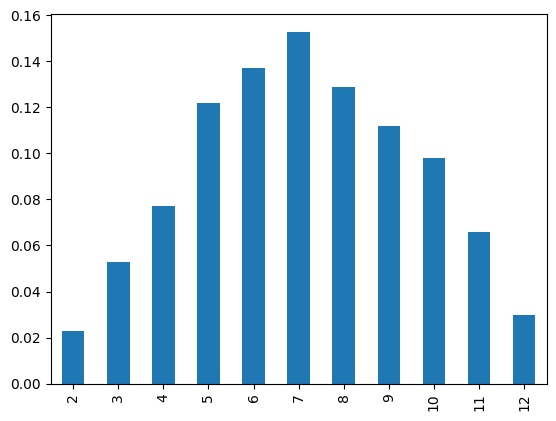

In [17]:
s = pd.Series(L)
(s.value_counts().sort_index()/len(s)).plot(kind='bar')

In [18]:
# Here PMF tells probability of X only

In [19]:
# Here distribution is approx normal

# **CDF in PMF**

<Axes: >

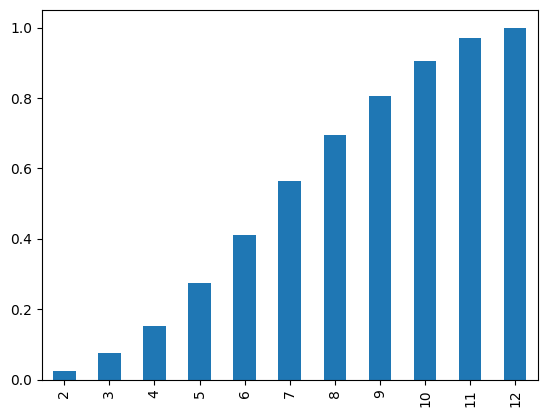

In [20]:
(s.value_counts().sort_index()/len(s)).cumsum().plot(kind='bar')

In [21]:
# here CDF tells probability of  X and less than 


# **Parametric Density Estimation**

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [23]:
sample = np.random.normal(loc=50,scale=5,size=1000) # loc: Mean , scale: std, size: number of values

(array([  4.,   4.,  50., 154., 268., 267., 159.,  67.,  23.,   4.]),
 array([32.00115418, 35.5491157 , 39.09707722, 42.64503873, 46.19300025,
        49.74096177, 53.28892329, 56.8368848 , 60.38484632, 63.93280784,
        67.48076935]),
 <BarContainer object of 10 artists>)

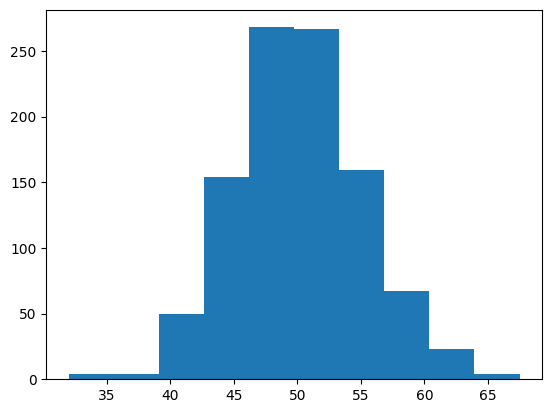

In [24]:
# plot histrogram to understand the disribution of data
plt.hist(sample,bins=10)

In [25]:
# calculate smaple mean and sample std 
print(f'Smaple Mean: {sample.mean():.2f}')
print(f'Sample Std: {sample.std():.2f}')

Smaple Mean: 50.17
Sample Std: 5.05


In [26]:
# fit the distribution with the above parametrs 
from scipy.stats import norm
dist = norm(sample.mean(),sample.std())

In [27]:
Values = np.linspace(sample.min(),sample.max(),100)

In [28]:
probabilities = [dist .pdf(value) for value in Values]

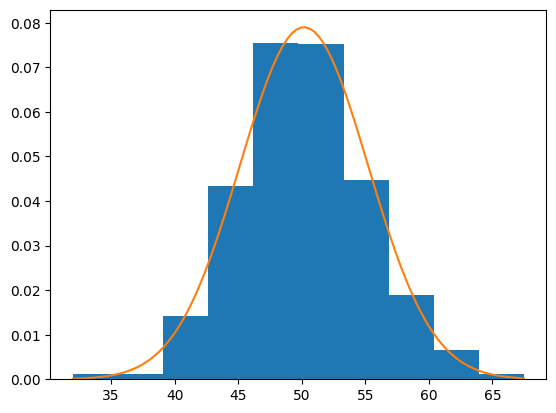

In [29]:
# plot the histrogram and pdf
plt.hist(sample,bins=10,density=True)
plt.plot(Values,probabilities)

<Axes: ylabel='Count'>

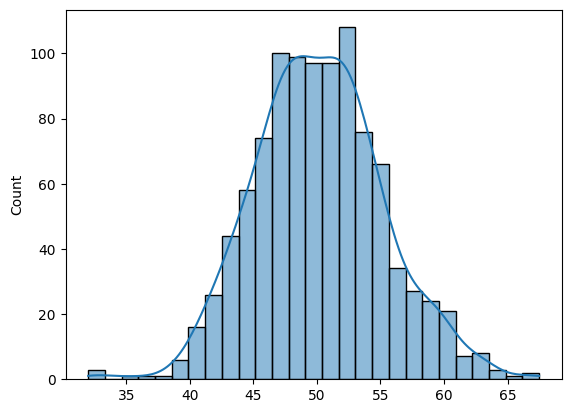

In [30]:
import seaborn as sns
sns.histplot(sample,kde=True)

# **Kernal Denstity Estimation(KDE)**

In [31]:
# Generate a sample 
sample1 = np.random.normal(loc=20,scale=5,size=300)
sample2 = np.random.normal(loc=40,scale=5,size=700)
sample = np.hstack((sample1,sample2))

(array([ 1.,  1.,  0.,  0.,  4.,  5.,  5.,  6., 14., 17., 19., 19., 21.,
        34., 21., 25., 21., 18., 15., 17., 13., 15.,  7., 11.,  9., 13.,
        18., 20., 35., 35., 33., 47., 56., 42., 60., 39., 56., 51., 48.,
        29., 30., 19., 16.,  7., 13.,  3.,  7.,  2.,  2.,  1.]),
 array([ 5.99065064,  6.97398085,  7.95731107,  8.94064128,  9.9239715 ,
        10.90730171, 11.89063193, 12.87396214, 13.85729235, 14.84062257,
        15.82395278, 16.807283  , 17.79061321, 18.77394343, 19.75727364,
        20.74060385, 21.72393407, 22.70726428, 23.6905945 , 24.67392471,
        25.65725493, 26.64058514, 27.62391535, 28.60724557, 29.59057578,
        30.573906  , 31.55723621, 32.54056643, 33.52389664, 34.50722685,
        35.49055707, 36.47388728, 37.4572175 , 38.44054771, 39.42387793,
        40.40720814, 41.39053835, 42.37386857, 43.35719878, 44.340529  ,
        45.32385921, 46.30718943, 47.29051964, 48.27384985, 49.25718007,
        50.24051028, 51.2238405 , 52.20717071, 53.19050093,

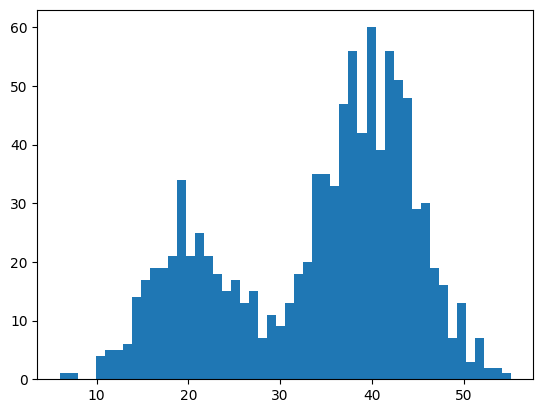

In [32]:
# Plot histrogram bins 50
plt.hist(sample,bins=50)

In [33]:
from sklearn.neighbors import KernelDensity

In [34]:
model = KernelDensity(bandwidth=3,kernel='gaussian') # bendwith : std, basically tickness of graph/curve 
# Convert data to 2d array
sample = sample.reshape([len(sample),1])
model.fit(sample)

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",3
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None


In [35]:
Values = np.linspace(sample.min(),sample.max(),100)
Values = Values.reshape([len(Values),1])

In [36]:
probabilities = model.score_samples(Values)
probabilities = np.exp(probabilities)

`score_samples(values)` returns the log density estimate of the input samples values .This is because the `score_samples()`<br> method of Kernal Density  class returns the 
logritham of the probability density estimate rather than the actual probability density estimation

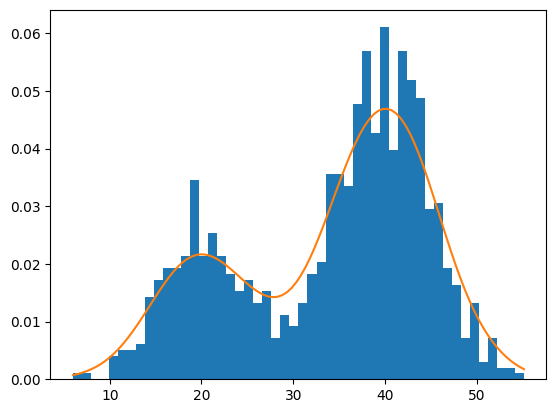

In [37]:
plt.hist(sample,bins=50,density=True)
plt.plot(Values[:],probabilities)
plt.show()

<Axes: ylabel='Density'>

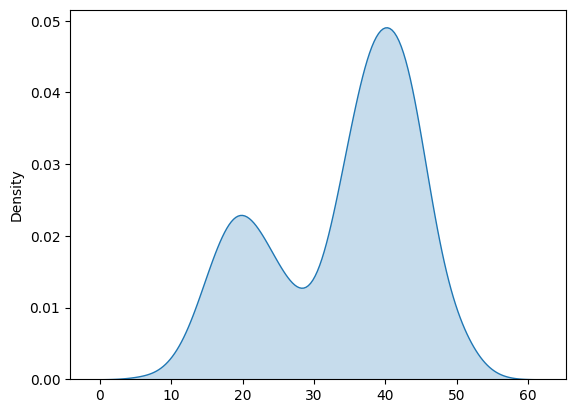

In [38]:
sns.kdeplot(sample.flatten(),bw_adjust=0.9,fill=True)

## **Use Of PDF  In Data Science**

In [39]:
df = sns.load_dataset('iris')

In [40]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='petal_length', ylabel='Density'>

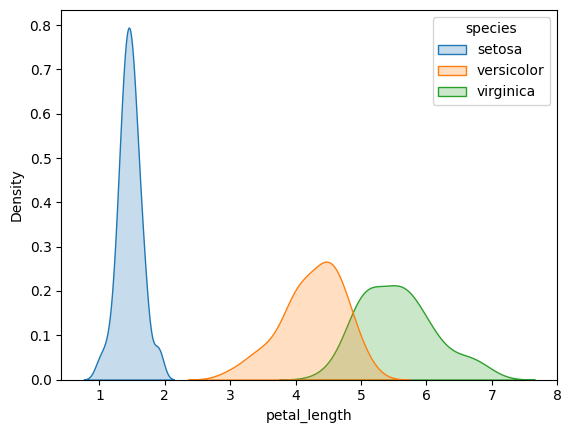

In [41]:
sns.kdeplot(data=df,x=df['petal_length'],hue=df['species'],fill=True)

<Axes: xlabel='petal_width', ylabel='Density'>

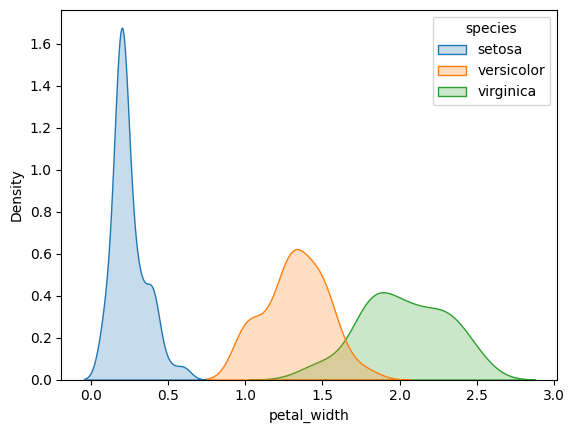

In [42]:
sns.kdeplot(data=df,x=df['petal_width'],hue=df['species'],fill=True)

<Axes: xlabel='sepal_length', ylabel='Density'>

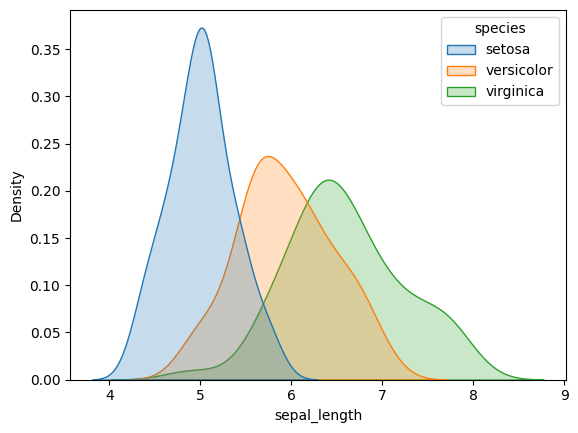

In [43]:
sns.kdeplot(data=df,x=df['sepal_length'],hue=df['species'],fill=True)

<Axes: xlabel='sepal_width', ylabel='Density'>

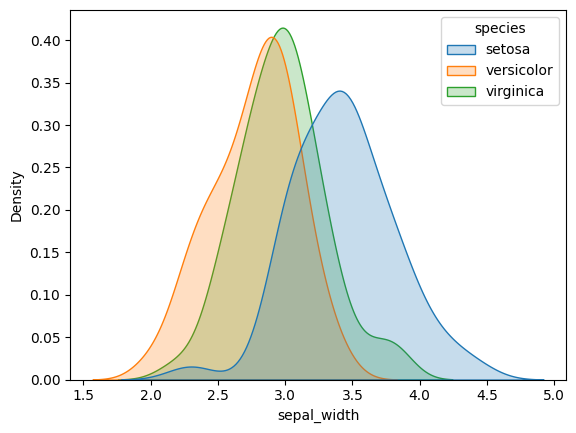

In [44]:
sns.kdeplot(data=df,x=df['sepal_width'],hue=df['species'],fill=True)

In [45]:
ti = pd.read_csv(r'c:\Users\LENOVO\Downloads\titanic.csv')
ti.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

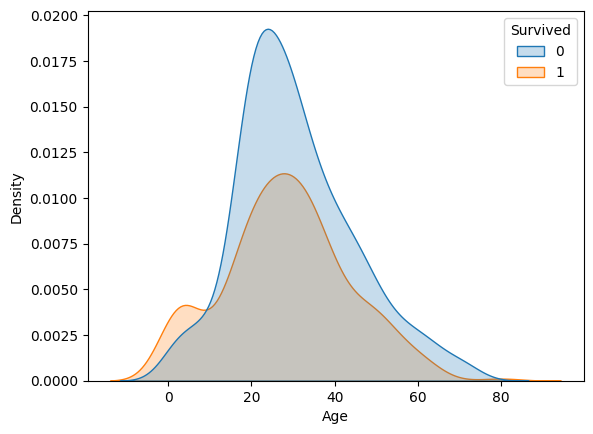

In [46]:
sns.kdeplot(data=ti,x=ti['Age'],hue=ti['Survived'],fill=True)

<Axes: xlabel='petal_width', ylabel='Density'>

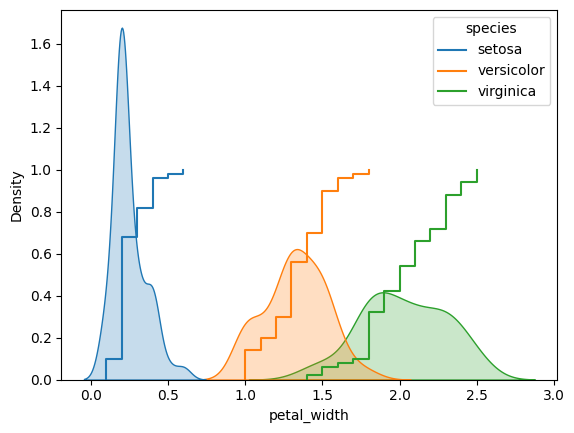

In [47]:
sns.kdeplot(data=df , x=df['petal_width'],hue=df['species'],fill=True)
sns.ecdfplot(data=df,x=df['petal_width'],hue=df['species'])

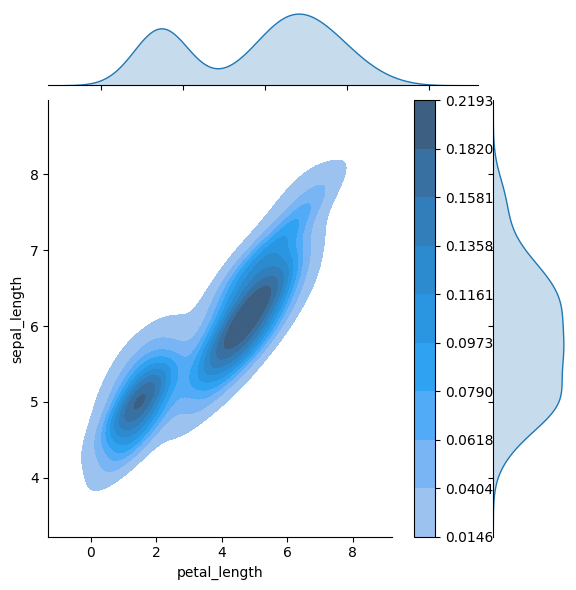

In [48]:
sns.jointplot(data=df,x = df['petal_length'],y= df['sepal_length'],kind='kde',cbar=True,fill = True)

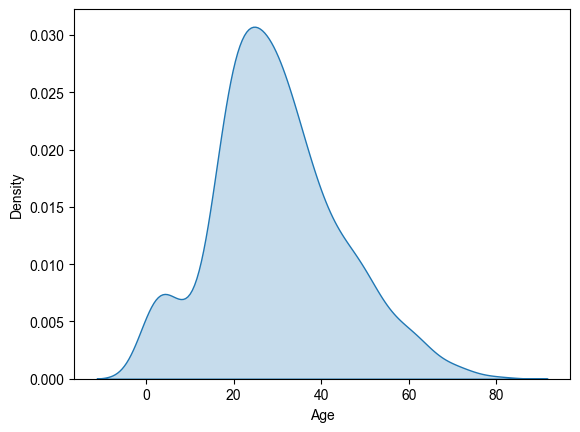

In [49]:
sns.kdeplot(data= ti, x=ti['Age'],fill=True)
sns.set_style('darkgrid')

In [50]:
Z = (ti['Age'] - ti['Age'].mean())/ti['Age'].std()

<Axes: xlabel='Age', ylabel='Density'>

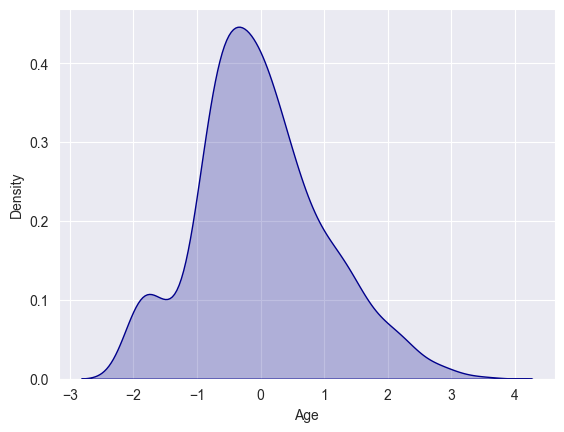

In [51]:
sns.kdeplot(x=Z,fill=True,color='darkblue')

In [52]:
Z.mean(),Z.std()

(np.float64(2.338621049070358e-16), np.float64(1.0))

In [53]:
ti['Age'].skew()
# Almost symmetric

np.float64(0.38910778230082704)

In [54]:
ti['Age'].mean() + 3*ti['Age'].std() # 97% population lies in this

np.float64(73.27860964406094)

In [55]:
ti[ti['Age'] > 73]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


In [56]:
# we can consider these 2 as ouliers as these are outside from 97% of population

## **QQ(Quantile-Quantile) Plot**

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns 

In [58]:
df = sns.load_dataset('iris')

<Axes: xlabel='sepal_length', ylabel='Density'>

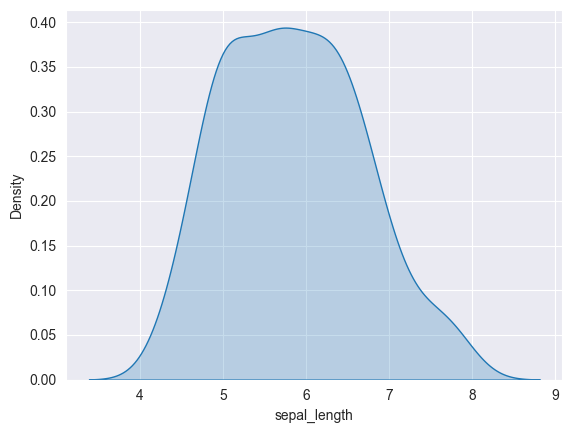

In [59]:
sns.kdeplot(df['sepal_length'],fill=True)

In [60]:
temp= sorted(df['sepal_length'].tolist())

In [61]:
y_quant = []
for i in range(1,101):
    y_quant.append(np.percentile(temp,i))

In [62]:
samples = np.random.normal(loc=0,scale=1,size=1000)

In [63]:
x_quant =  []
for  i in range(1,101):
    x_quant.append(np.percentile(samples,i))

<Axes: >

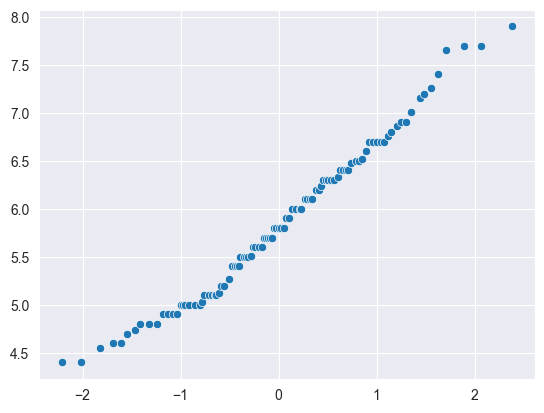

In [64]:
sns.scatterplot(x= x_quant,y= y_quant)

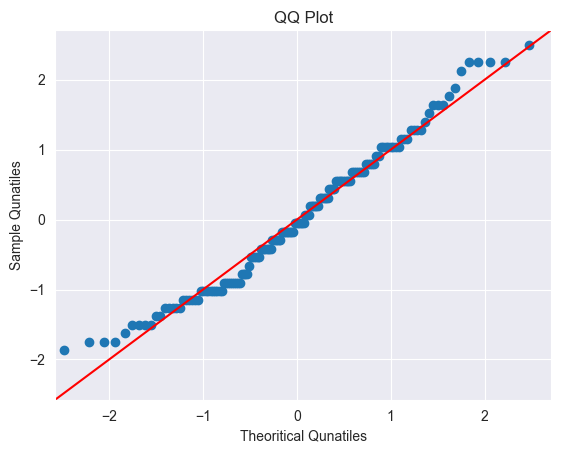

In [65]:
# using statsmodule
import statsmodels.api as sm
import matplotlib.pyplot  as plt

# Create a QQ plot of the two sets of data 
fig = sm.qqplot(df['sepal_length'],line='45',fit=True)

# Add title and labels to the plot
plt.title('QQ Plot')
plt.xlabel('Theoritical Qunatiles')
plt.ylabel('Sample Qunatiles')

# show the plot
plt.show()

# **Log Log Plot**

In [66]:
import numpy as np
import matplotlib.pyplot as plt

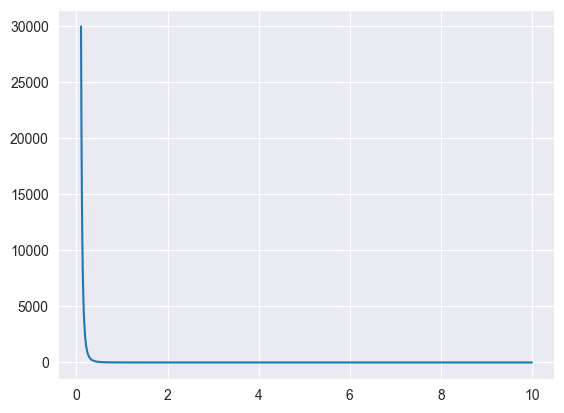

In [67]:
# Difine the paremeteres of the pareto Distribution
alpha = 3
xm = 1

# create an array of x values 
x = np.linspace(0.1,10,1000)

# calculate the y values of the pareto Distribution
y = alpha *(xm**alpha)/(x**(alpha+1))

plt.plot(x,y)

Text(0.5, 0, 'X')

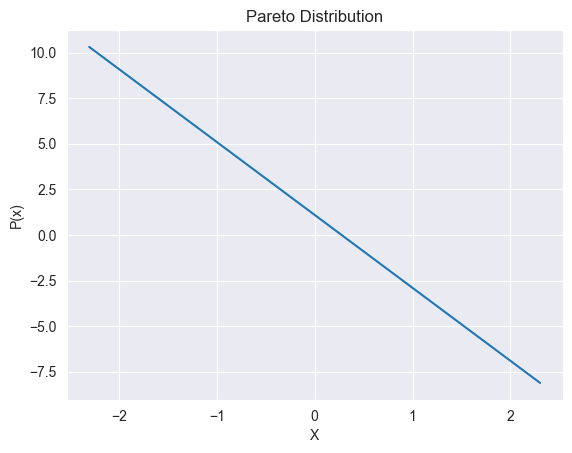

In [68]:
# create the log-log plot
plt.plot(np.log(x),np.log(y))

# add labels and a title 
plt.title('Pareto Distribution')
plt.ylabel('P(x)')
plt.xlabel('X')

In [69]:
import scipy.stats as stats
import statsmodels.api as sm

In [70]:
# Difine the distribution of the pareto Distribution
alpha =2 
xm = 1

# Generate a set of random data from the pareto distribution
x = stats.pareto.rvs(b = alpha, scale = xm, size=1000)

(array([922.,  43.,  17.,   8.,   2.,   4.,   1.,   1.,   1.,   1.]),
 array([ 1.0018666 ,  3.26103125,  5.52019591,  7.77936057, 10.03852522,
        12.29768988, 14.55685454, 16.81601919, 19.07518385, 21.33434851,
        23.59351316]),
 <BarContainer object of 10 artists>)

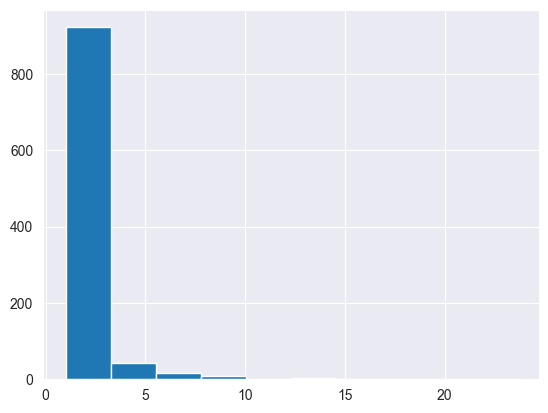

In [71]:
plt.hist(x)

In [72]:
# fit a pareto distribution to the data 
params = stats.pareto.fit(x,floc= 0)

# create a pareto distribution object with the fitted parameters 
dist = stats.pareto(b=params[0],scale  = params[2])

<Axes: xlabel='Age', ylabel='Density'>

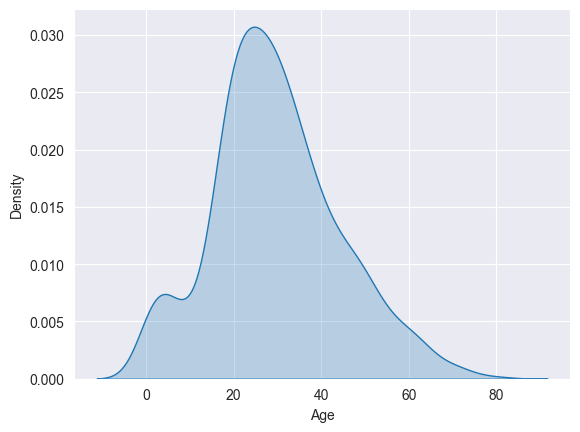

In [74]:
sns.kdeplot(x = ti['Age'],data=ti,fill=True)

In [78]:
print(f'Before Log Transform : {ti['Age'].skew():.2f}')
print(f'After Log Transform: {np.log(ti['Age']).skew():.2f}')

Before Log Transform : 0.39
After Log Transform: -2.30


<Axes: xlabel='Age', ylabel='Density'>

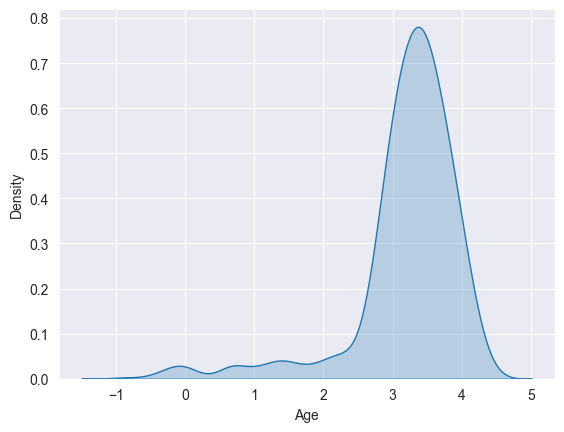

In [75]:
x = np.log(ti['Age'])
sns.kdeplot(x = x,data=ti,fill=True)